In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "Ready_data").exists() and (candidate / "Data").exists()
)
READY_DIR = PROJECT_ROOT / "Ready_data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

eligibility_matrix = pd.read_csv(
    READY_DIR / "rebalance_universe_matrix.csv",
    index_col=0,
    parse_dates=True,
)
eligibility_matrix = (
    eligibility_matrix
    .replace({"True": True, "False": False, "1": True, "0": False})
    .fillna(False)
    .astype(bool)
    .sort_index()
)

eligible_once = eligibility_matrix.any(axis=0)
eligible_tickers = eligible_once[eligible_once].index.tolist()
eligibility_matrix = eligibility_matrix.reindex(columns=eligible_tickers).fillna(False)

In [ ]:
import importlib
import bayesian_factor_inputs2

importlib.reload(bayesian_factor_inputs2)
from bayesian_factor_inputs2 import build_bayesian_factor_inputs

factor_outputs = build_bayesian_factor_inputs(
    project_root=PROJECT_ROOT)

rf_df = factor_outputs['rf_df']
equity_factors_df = factor_outputs['equity_factors']
macro_factors_df = factor_outputs['macro_factors_df']
bond_factors_df = factor_outputs['bond_factors_df']

raw_equity_factors_df = factor_outputs['raw_equity_factors_df']
raw_macro_factors_df = factor_outputs['raw_macro_factors_df']
raw_bond_factors_df = factor_outputs['raw_bond_factors_df']
raw_factor_blocks_df = factor_outputs['raw_factor_blocks_df']

transformed_equity_factors_df = factor_outputs['transformed_equity_factors_df']
transformed_macro_factors_df = factor_outputs['transformed_macro_factors_df']
transformed_bond_factors_df = factor_outputs['transformed_bond_factors_df']
transformed_factor_blocks_df = factor_outputs['transformed_factor_blocks_df']
asset_class_series = factor_outputs['asset_class_series']
tcost_df = factor_outputs['tcost_df']
monthly_simple_returns = factor_outputs['monthly_simple_returns']
monthly_excess_returns = factor_outputs['monthly_excess_returns']

display(
    pd.DataFrame(
        {
            'block': [
                'rf_df',
                'equity_factors',
                'macro_factors_df',
                'bond_factors_df',
                'raw_factor_blocks_df',
                'transformed_factor_blocks_df',
                'asset_class_series',
                'tcost_df',
                'monthly_simple_returns',
                'monthly_excess_returns',
            ],
            'shape': [
                rf_df.shape,
                equity_factors_df.shape,
                macro_factors_df.shape,
                bond_factors_df.shape,
                raw_factor_blocks_df.shape,
                transformed_factor_blocks_df.shape,
                asset_class_series.shape,
                tcost_df.shape,
                monthly_simple_returns.shape,
                monthly_excess_returns.shape,
            ],
        }
    )
)


,block,shape
0,rf_df,"(119, 1)"
1,equity_factors,"(119, 6)"
2,macro_factors_df,"(119, 9)"
3,bond_factors_df,"(119, 1)"
4,raw_factor_blocks_df,"(119, 16)"
5,transformed_factor_blocks_df,"(119, 16)"
6,asset_class_series,"(3554,)"
7,tcost_df,"(119, 3)"
8,monthly_simple_returns,"(119, 3130)"
9,monthly_excess_returns,"(119, 3130)"


In [ ]:
import importlib
import hierarchical_bayesian_etf_model
import hierarchical_portfolio_backtest

importlib.reload(hierarchical_bayesian_etf_model)
importlib.reload(hierarchical_portfolio_backtest)
from hierarchical_portfolio_backtest import (
    HierarchicalBacktestConfig,
    run_backtest,
    build_live_diagnostics_table,
    compute_portfolio_performance_summary,
    summarize_model_performance,
    format_metric_table,
    plot_balance_and_drawdown,
)

FACTOR_TOGGLE_DEFAULT = True
FACTOR_TOGGLES = {
    "macro::inflation": True,
    "macro::real interest rates": True,
    "macro::term structure": True,
    "macro::SOFR O/N": True,
    "macro::MM_12M": True,
    "macro::IG OAS": True,
    "macro::HY OAS": True,
    "macro::NY Fed recession": True,
    "macro::VIX": True,
    "equity::Mkt-RF": True,
    "equity::SMB": True,
    "equity::HML": True,
    "equity::RMW": True,
    "equity::CMA": True,
    "equity::Mom": True,
    "bond::duration": True,
}

config = HierarchicalBacktestConfig(
    warmup_months=36,
    window_type='rolling',
    rolling_window_months=36,
    min_obs=24,
    min_eligible_etfs=5,
    n_posterior_draws=1500,
    n_scenario_draws=1500,
    credible_interval_level=0.95,
    cvar_alpha=0.95,
    cvar_budget=0.08,
    turnover_penalty=0.003,
    transaction_cost_bps=10.0,
    min_weight=0.0,
    active_min_weight=0.0005,
    max_weight=0.3,
    partial_adjustment_alpha=0.8,
    residual_ewma_decay=0.96,
    factor_cov_ewma_decay=0.96,
    residual_lookback_months=60,
    factor_cov_lookback_months=60,
    covariance_shrinkage=0.35,
    covariance_shrink_target='constant_correlation',
    min_cov_history_obs=24,
    scenario_distribution='student_t',
    student_t_df=7.0,
    solver='CLARABEL',
    random_state=42,
    forecast_mode='mean_zero',
    model_n_iter=15,
    alpha_prior_var=1e-4,
    macro_prior_var=0.15,
    style_prior_var=0.15,
    alpha_group_mean_var=1e-4,
    macro_group_mean_var=0.15,
    style_group_mean_var=0.15,
    # coef_prior_spec={"family": "gaussian"},
    # coef_prior_spec={"family": "laplace", "max_iter": 1000, "tol": 1e-6},
    coef_prior_spec={"family": "horseshoe_approx", "global_scale": 1.0, "local_scale": 1.0},
    residual_var_floor=1e-6,
    initial_portfolio_balance=1000.0,
    show_progress=True,
    print_monthly_log=True,
    print_skips=True,
    factor_toggles=FACTOR_TOGGLES,
    factor_toggle_default=FACTOR_TOGGLE_DEFAULT,
)

HierarchicalBacktestConfig(warmup_months=36, window_type='rolling', rolling_window_months=36, min_obs=24, max_train_missing_frac=0.25, min_eligible_etfs=5, n_posterior_draws=1500, n_scenario_draws=1500, credible_interval_level=0.95, cvar_alpha=0.95, cvar_budget=0.08, turnover_penalty=0.003, transaction_cost_bps=10.0, min_weight=0.0, active_min_weight=0.0005, max_weight=0.3, partial_adjustment_alpha=0.8, residual_ewma_decay=0.96, factor_cov_ewma_decay=0.96, residual_lookback_months=60, factor_cov_lookback_months=60, covariance_shrinkage=0.35, covariance_shrink_target='constant_correlation', min_cov_history_obs=24, scenario_distribution='student_t', student_t_df=7.0, solver='CLARABEL', random_state=42, forecast_mode='mean_zero', model_n_iter=15, alpha_prior_var=0.0001, macro_prior_var=0.15, style_prior_var=0.15, alpha_group_mean_var=0.0001, macro_group_mean_var=0.15, style_group_mean_var=0.15, coef_prior_spec={'family': 'horseshoe_approx', 'global_scale': 1.0, 'local_scale': 1.0}, residu

In [9]:
backtest_result = run_backtest(
    monthly_simple_returns=monthly_simple_returns,
    monthly_excess_returns=monthly_excess_returns,
    eligibility_matrix=eligibility_matrix,
    asset_class_series=asset_class_series,
    macro_factors_df=macro_factors_df,
    equity_factors_df=equity_factors_df,
    bond_factors_df=bond_factors_df,
    config=config,
)


Hierarchical ETF backtest:   1%|          | 1/83 [00:19<27:08, 19.86s/it, cost=0.10%, month=2019-01-31, month_net=4.86%, nav_net=1,048.56, total_net=4.86%, turnover=100.00%]

[2019-01-31 -> 2019-02-28] month_net=4.86%, total_net=4.86%, nav_net=1,048.56, turnover=100.00%, cost_drag=0.10%


Hierarchical ETF backtest:   2%|▏         | 2/83 [00:40<27:23, 20.29s/it, cost=0.02%, month=2019-02-28, month_net=2.34%, nav_net=1,073.08, total_net=7.31%, turnover=20.56%] 

[2019-02-28 -> 2019-03-31] month_net=2.34%, total_net=7.31%, nav_net=1,073.08, turnover=20.56%, cost_drag=0.02%


Hierarchical ETF backtest:   4%|▎         | 3/83 [00:58<25:45, 19.32s/it, cost=0.01%, month=2019-03-31, month_net=4.89%, nav_net=1,125.55, total_net=12.55%, turnover=6.86%]

...

[2025-09-30 -> 2025-10-31] month_net=4.84%, total_net=169.52%, nav_net=2,695.24, turnover=21.28%, cost_drag=0.02%


Hierarchical ETF backtest:  99%|█████████▉| 82/83 [30:07<00:25, 25.33s/it, cost=0.00%, month=2025-10-31, month_net=-1.81%, nav_net=2,646.51, total_net=164.65%, turnover=3.54%]

[2025-10-31 -> 2025-11-30] month_net=-1.81%, total_net=164.65%, nav_net=2,646.51, turnover=3.54%, cost_drag=0.00%


Hierarchical ETF backtest: 100%|██████████| 83/83 [30:32<00:00, 22.08s/it, cost=0.02%, month=2025-11-30, month_net=0.73%, nav_net=2,665.71, total_net=166.57%, turnover=24.91%]

[2025-11-30 -> 2025-12-31] month_net=0.73%, total_net=166.57%, nav_net=2,665.71, turnover=24.91%, cost_drag=0.02%


,prediction_date,model_n_etfs_used,realized_net_return,portfolio_total_return_net,turnover,transaction_cost,monthly_waic,monthly_rank_ic,monthly_log_score,scenario_expected_return,scenario_cvar,scenario_portfolio_var,scenario_portfolio_cvar,var_breach,cvar_breach,skipped,skip_reason
rebalance_date,,,,,,,,,,,,,,,,,
2019-01-31,2019-02-28,556,0.048565,0.048565,1.000000,0.001000,239892.866965,0.524651,1174.749826,0.022655,0.08,-0.054979,-0.072562,0.0,0.0,False,None
2019-02-28,2019-03-31,557,0.023380,0.073080,0.205550,0.000206,312301.805984,-0.107277,1130.167630,0.023462,0.08,-0.056644,-0.078686,0.0,0.0,False,None
2019-03-31,2019-04-30,563,0.048896,0.125549,0.068593,0.000069,261301.743638,0.536238,1178.851937,0.021889,0.08,-0.058686,-0.080174,0.0,0.0,False,None
2019-04-30,2019-05-31,566,-0.105729,0.006546,0.151527,0.000152,960960.709472,-0.503154,585.101596,0.023086,0.08,-0.056579,-0.081222,1.0,1.0,False,None
2019-05-31,2019-06-30,570,0.116037,0.123343,0.117385,0.000117,555404.999635,0.557385,891.522172,0.018928,0.08,-0.059755,-0.081385,0.0,0.0,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-31,2025-08-31,734,0.024271,1.450070,0.110064,0.000110,359349.461102,0.114116,1436.912252,0.020156,0.08,-0.059629,-0.080357,0.0,0.0,False,None
2025-08-31,2025-09-30,734,0.050369,1.573478,0.248000,0.000248,308577.506602,0.464257,1517.790841,0.022375,0.08,-0.059314,-0.080543,0.0,0.0,False,None
2025-09-30,2025-10-31,733,0.048394,1.698018,0.215567,0.000216,328440.125680,0.315122,1503.233393,0.026324,0.08,-0.057539,-0.076096,0.0,0.0,False,None


,Metric,Value
0,Annualized Return,15.25%
1,Annualized Volatility,17.95%
2,Cumulative Return,166.88%
3,Sharpe Ratio,0.7398
4,Sortino Ratio,1.1787
5,Treynor Ratio,0.1367
6,Calmar Ratio,0.4701
7,VaR 95%,-9.54%
8,CVaR 95%,-10.51%
9,Downside Deviation,11.27%


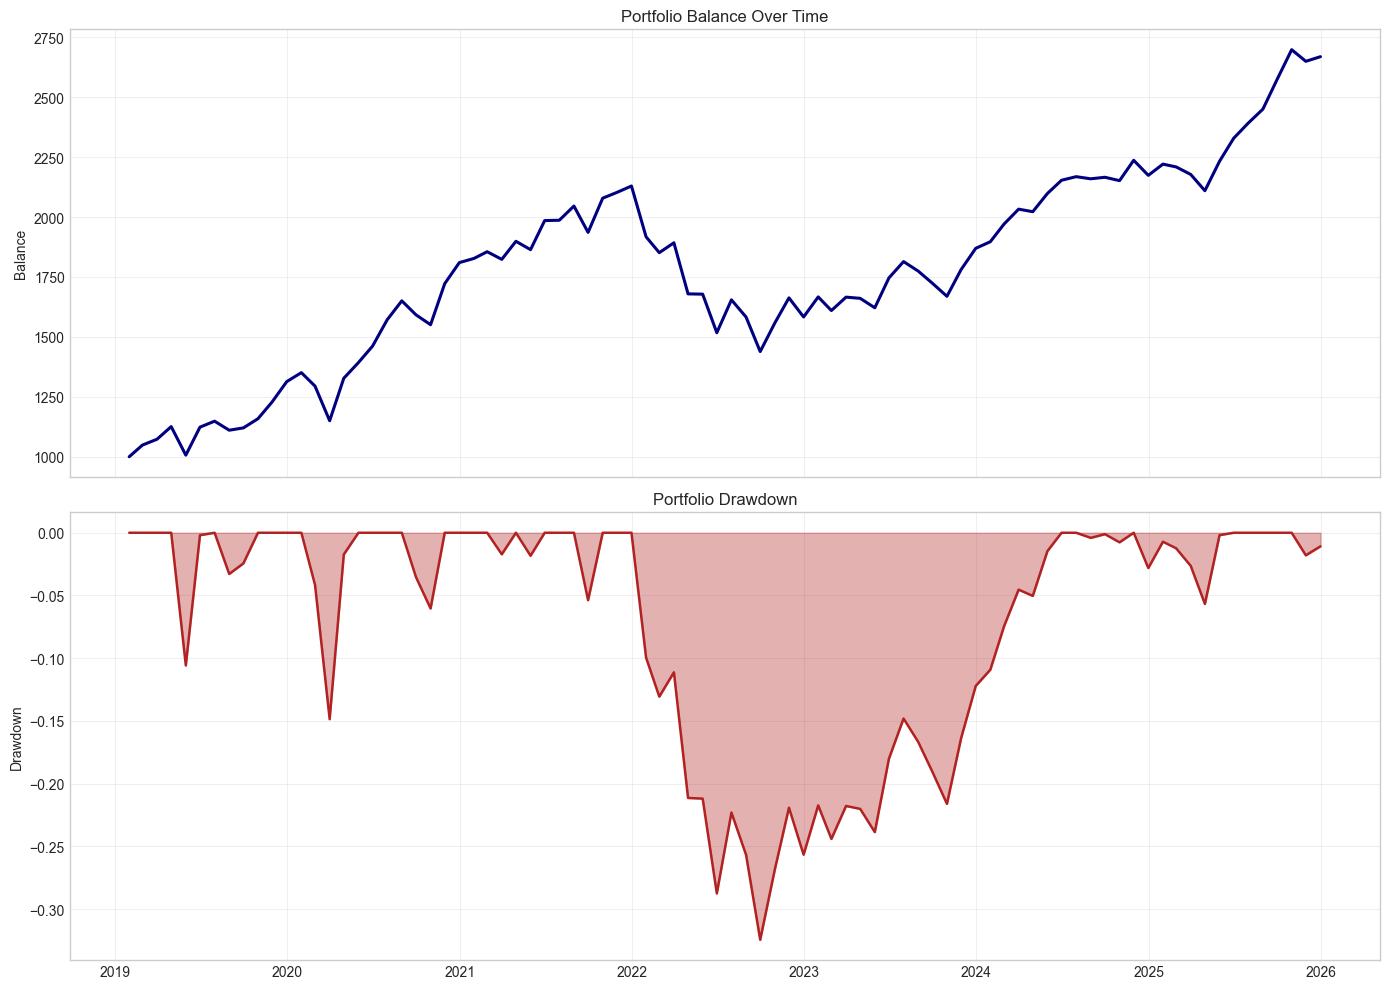

,Metric,Value
0,Predictive Log Score (Mean),1.4112
1,Predictive Log Score (Total),75225.3841
2,WAIC,42443372.8997
3,Rank IC (Mean Spearman),0.0930
4,Rank IC (Median Spearman),0.1033
5,MAE,0.0398
6,RMSE,0.0584
7,95% Credible Interval Coverage,95.65%
8,Forecast Count,53306


,mean_log_score,waic,mae,rmse,coverage,n_forecasts,rank_ic
prediction_date,,,,,,,
2019-02-28,2.112859,239892.866965,0.020708,0.027044,1.000000,556,0.524651
2019-03-31,2.029026,312301.805984,0.017952,0.026073,0.980251,557,-0.107277
2019-04-30,2.093876,261301.743638,0.022747,0.030117,1.000000,563,0.536238
2019-05-31,1.033748,960960.709472,0.066743,0.078373,0.745583,566,-0.503154
2019-06-30,1.564074,555404.999635,0.051815,0.060399,0.992982,570,0.557385
...,...,...,...,...,...,...,...
2025-08-31,1.957646,359349.461102,0.029054,0.061686,0.997275,734,0.114116
2025-09-30,2.067835,308577.506602,0.022480,0.041466,1.000000,734,0.464257
2025-10-31,2.050796,328440.125680,0.020219,0.034298,0.997271,733,0.315122


In [ ]:
diagnostics_table = build_live_diagnostics_table(backtest_result)
display(diagnostics_table)

portfolio_summary = compute_portfolio_performance_summary(
    backtest_result=backtest_result,
    rf_series=rf_df['RF'],
    benchmark_excess_series=equity_factors_df['Mkt-RF'],
    alpha=config.cvar_alpha,
)
display(
    format_metric_table(
        portfolio_summary,
        percent_metrics={
            'Annualized Return',
            'Annualized Volatility',
            'Cumulative Return',
            f"VaR {int(config.cvar_alpha * 100)}%",
            f"CVaR {int(config.cvar_alpha * 100)}%",
            'Downside Deviation',
            'VaR Breach Rate',
            'CVaR Breach Rate',
            'Max Drawdown',
        },
    )
)

plot_balance_and_drawdown(backtest_result)

model_summary, model_by_month = summarize_model_performance(backtest_result)
display(
    format_metric_table(
        model_summary,
        percent_metrics={'95% Credible Interval Coverage'},
    )
)
display(model_by_month)


Saved table image to: C:\Projects\Factor Model\FINAL\notebooks\strategy_performance_summary_table.png


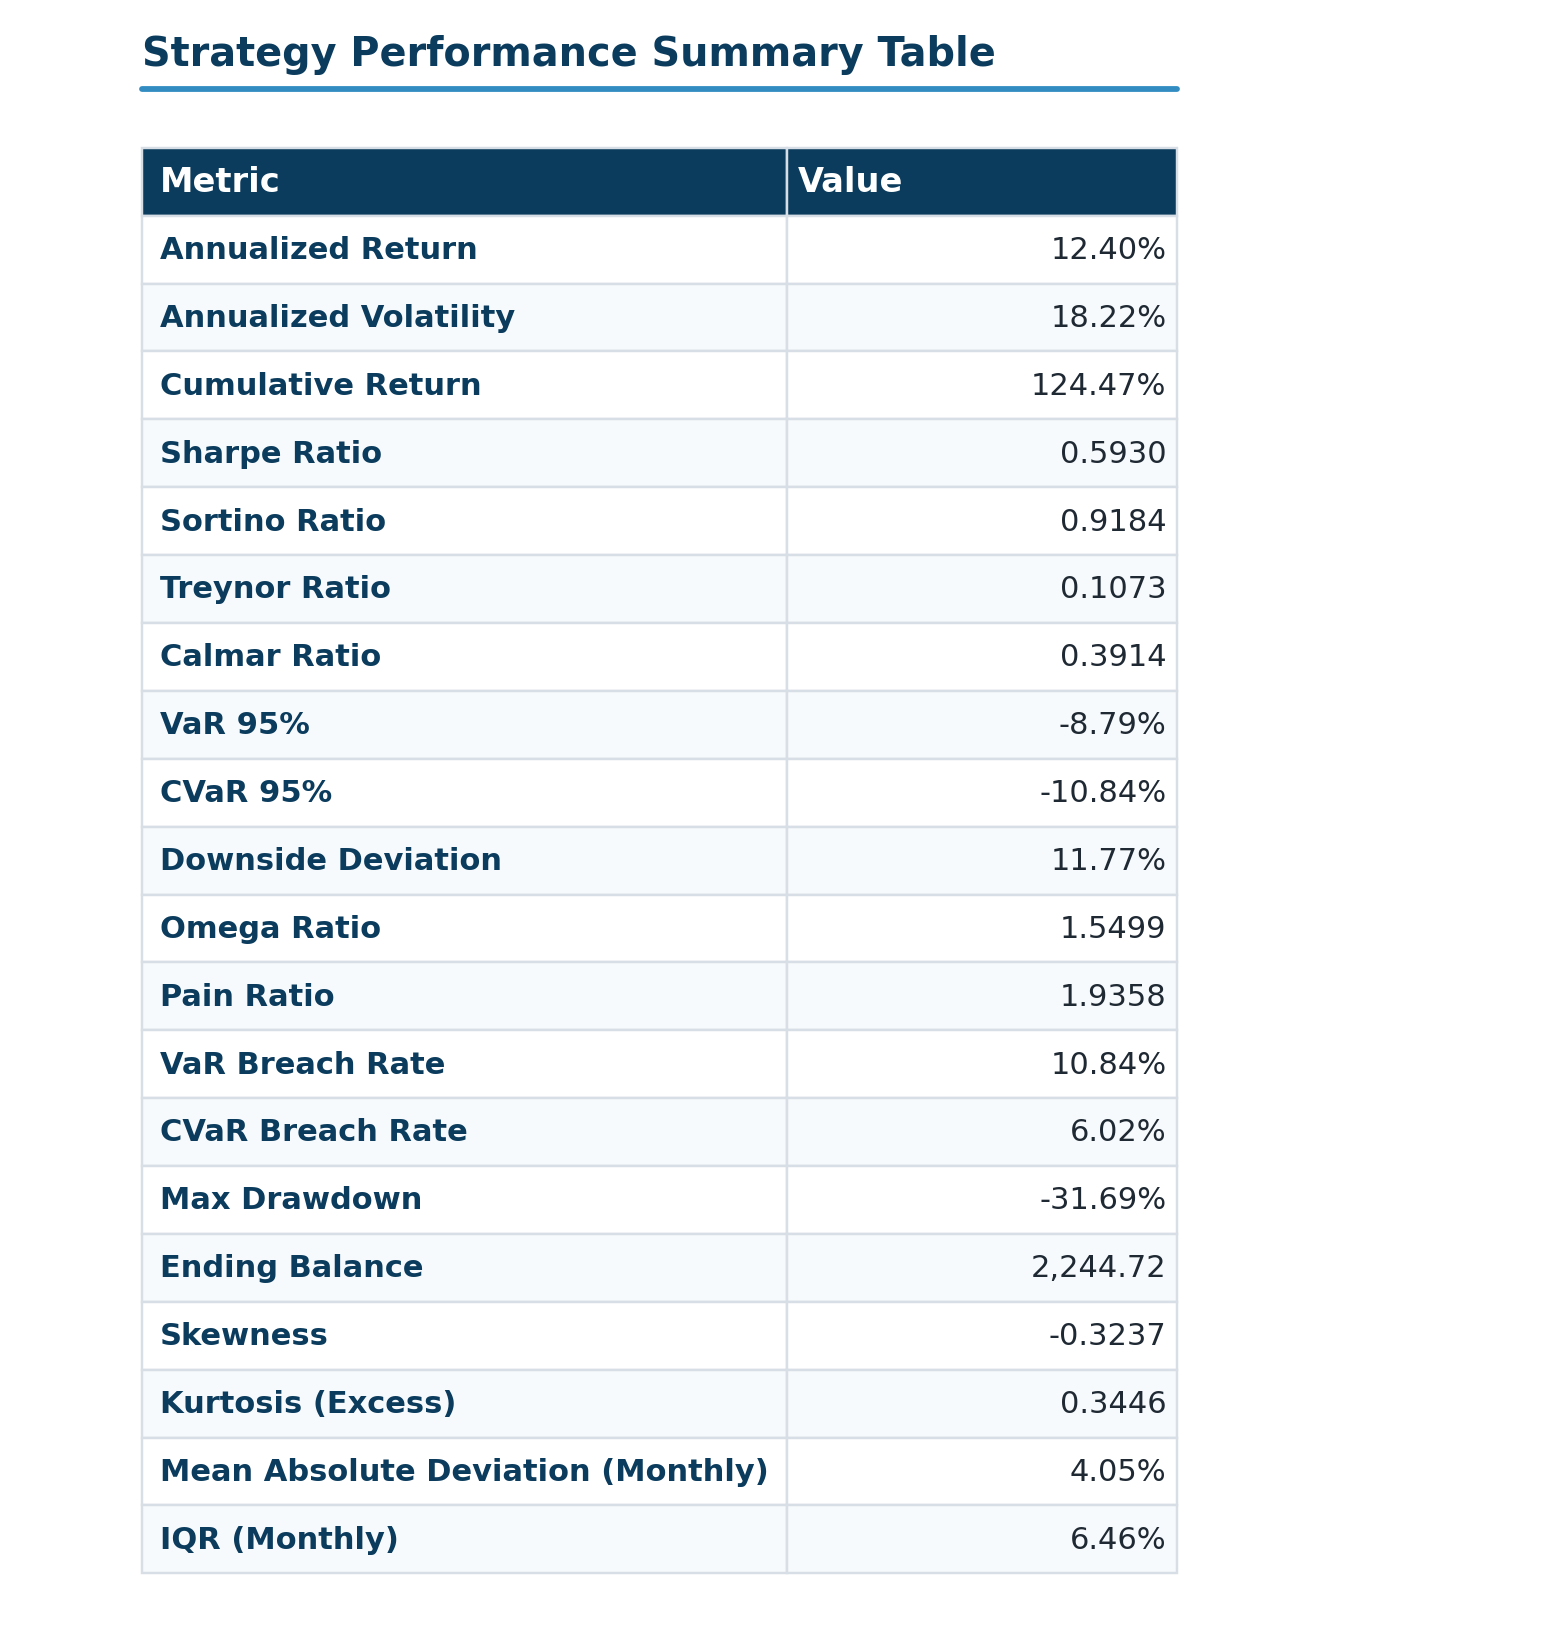

In [ ]:
table_palette = {
    "navy": "#0B3C5D",
    "blue": "#328CC1",
    "green": "#5AA469",
    "orange": "#F26419",
    "slate": "#7B8C99",
    "grid": "#D7DEE5",
    "alt": "#F7FAFC",
}

metrics_for_image = portfolio_summary_full.reset_index(drop=True).copy()
n_rows = len(metrics_for_image)
fig_height = max(6.3, 0.39 * n_rows + 1.55)

fig, ax = plt.subplots(figsize=(8.8, fig_height), dpi=220)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

ax.text(
    0.08,
    0.992,
    "Strategy Performance Summary Table",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold",
    color=table_palette["navy"],
)
ax.plot([0.08, 0.77], [0.957, 0.957], transform=ax.transAxes, color=table_palette["blue"], linewidth=1.9)

tbl = ax.table(
    cellText=metrics_for_image.values.tolist(),
    colLabels=["Metric", "Value"],
    colLoc="left",
    cellLoc="left",
    bbox=[0.08, 0.02, 0.69, 0.90],
    colWidths=[0.43, 0.26],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.16)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(table_palette["grid"])
    cell.set_linewidth(0.8)
    cell.PAD = 0.028
    if row == 0:
        cell.set_facecolor(table_palette["navy"])
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
        cell.get_text().set_fontsize(11)
    else:
        cell.set_facecolor(table_palette["alt"] if row % 2 == 0 else "white")
        if col == 0:
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_color(table_palette["navy"])
        else:
            cell.get_text().set_color("#1F2933")

for row in range(1, n_rows + 1):
    tbl[row, 0].get_text().set_ha("left")
    tbl[row, 1].get_text().set_ha("right")
tbl[0, 0].get_text().set_ha("left")
tbl[0, 1].get_text().set_ha("left")

cwd = Path.cwd()
if cwd.name.lower() == "notebooks":
    output_path = cwd / "strategy_performance_summary_table.png"
else:
    output_path = cwd / "notebooks" / "strategy_performance_summary_table.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=220, facecolor="white", bbox_inches="tight", pad_inches=0.03)
print(f"Saved table image to: {output_path.resolve()}")
plt.show()


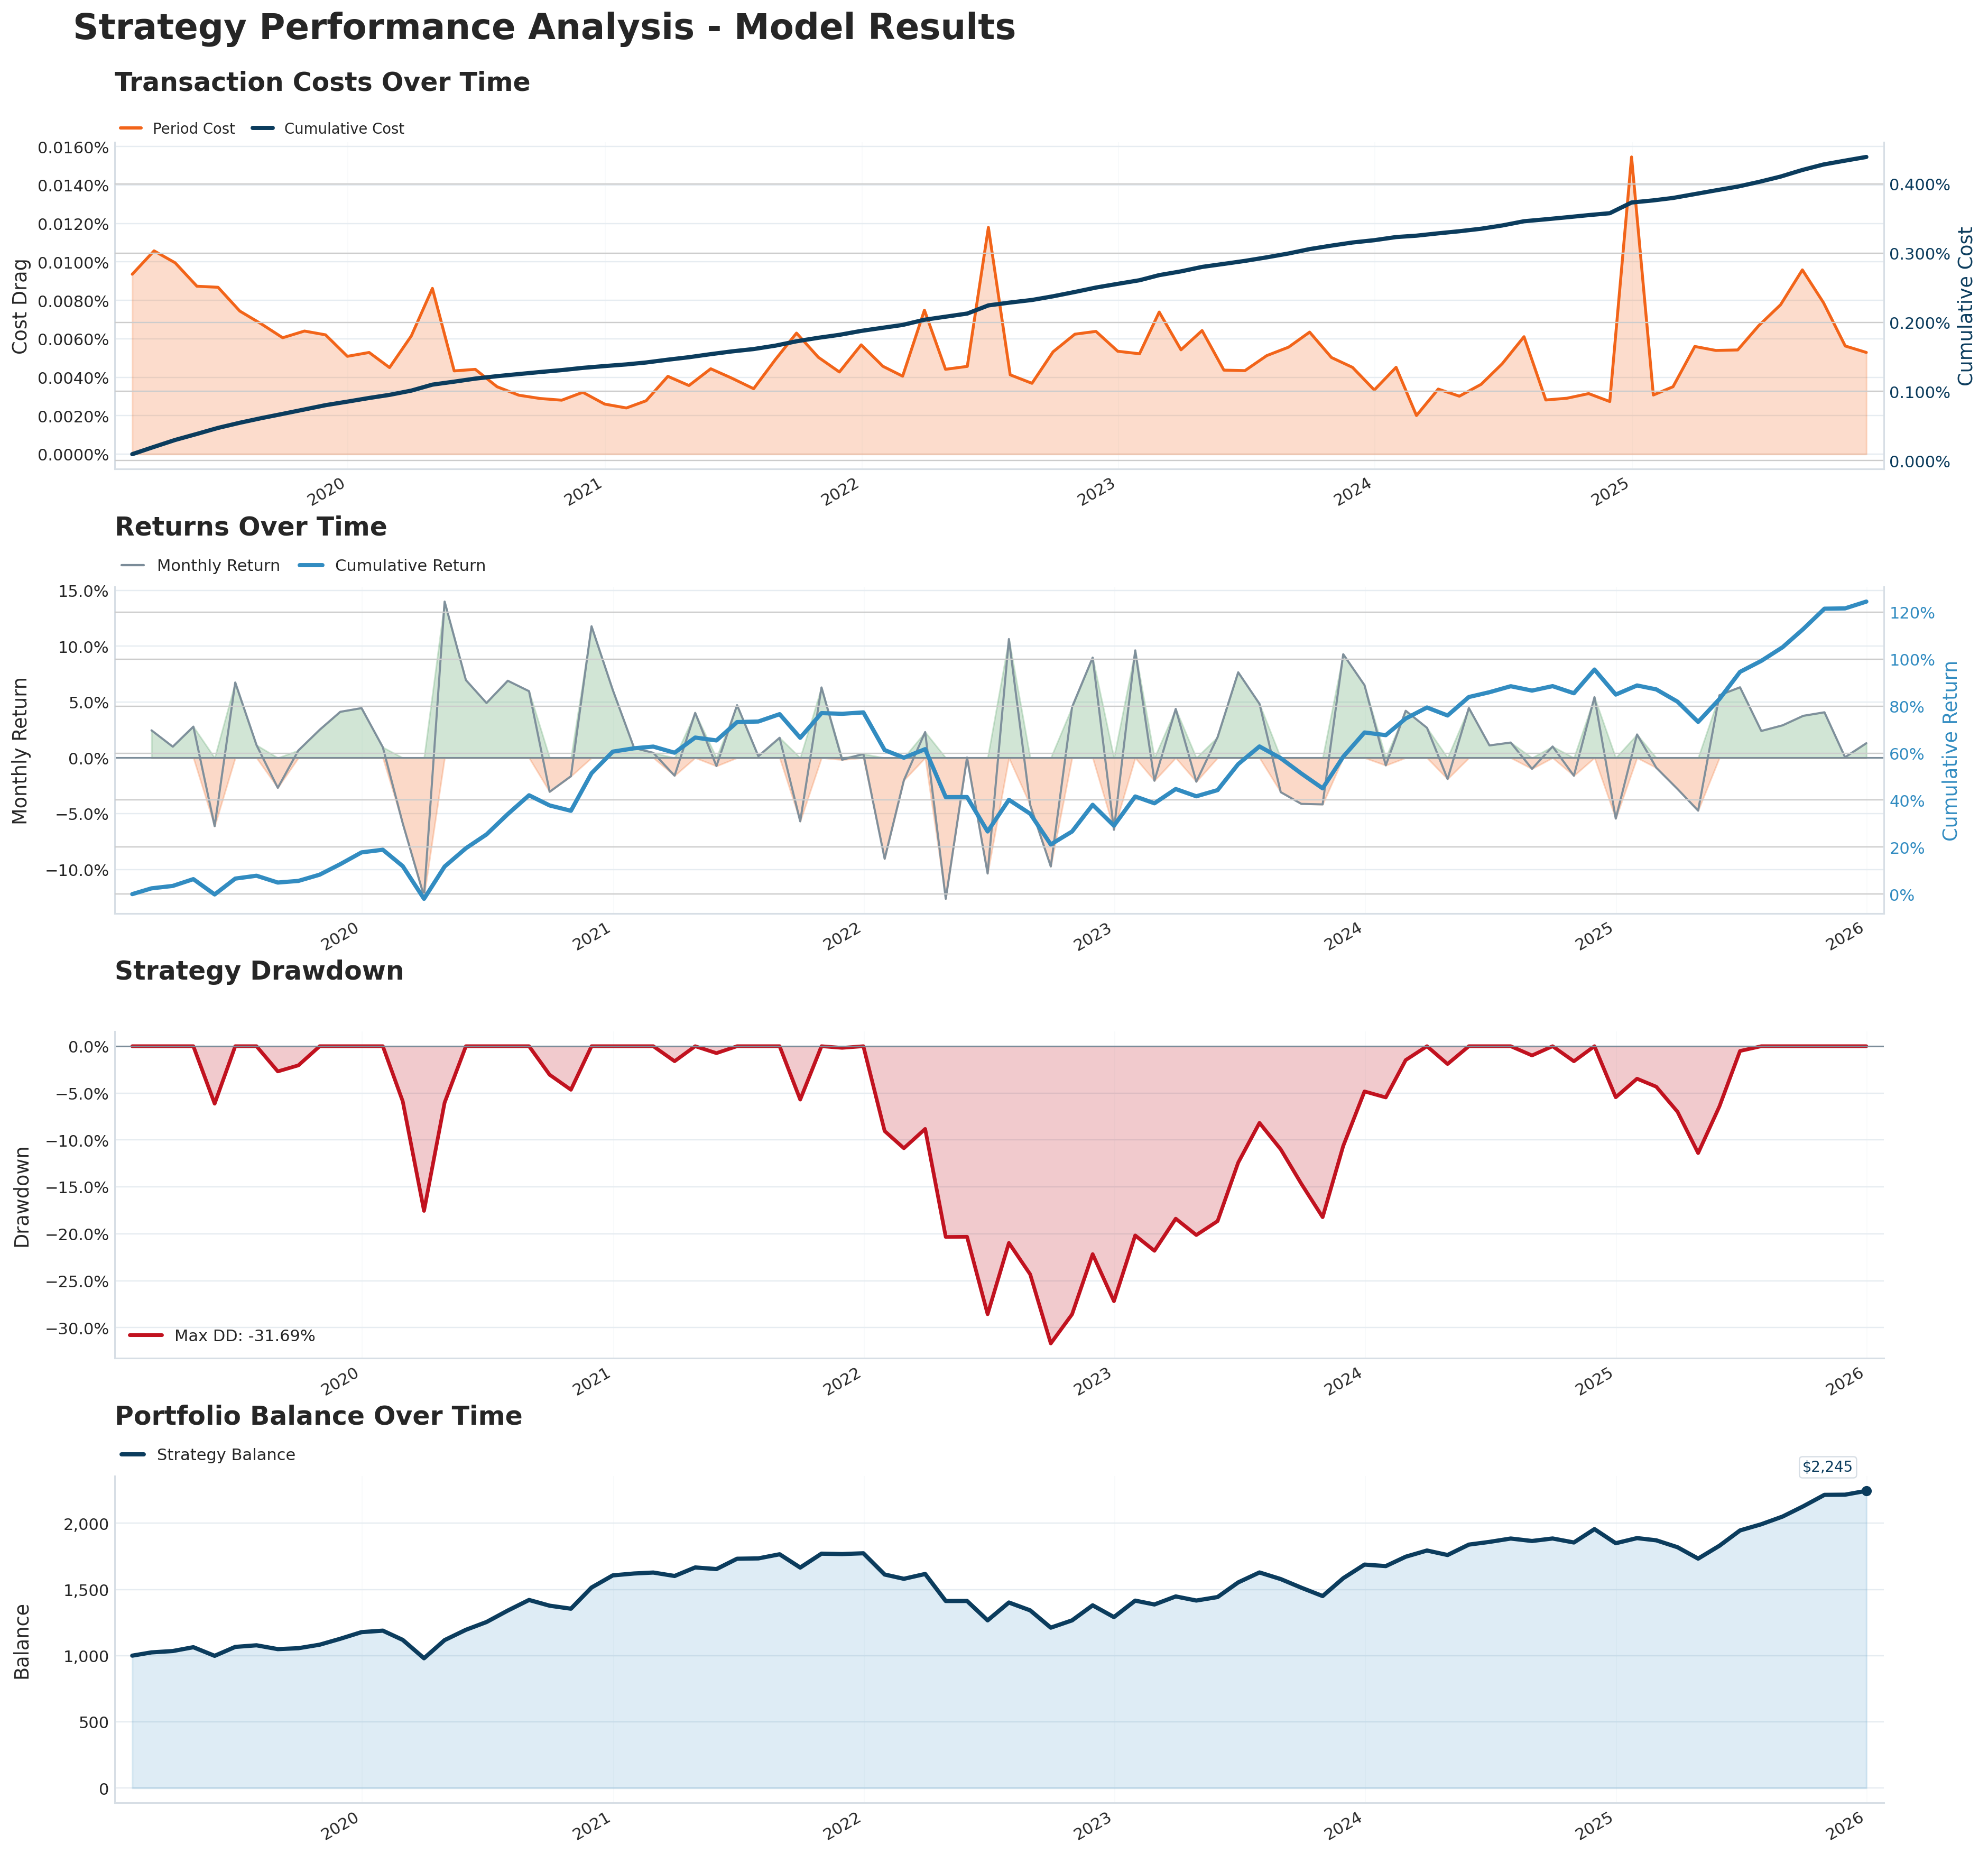

In [ ]:
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

STYLE_PALETTE = [
    "#0B3C5D",
    "#328CC1",
    "#5AA469",
    "#F6AE2D",
    "#F26419",
    "#7B8C99",
    "#B8C4CE",
]

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#D7DEE5",
        "axes.linewidth": 1.0,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.family": "DejaVu Sans",
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
    }
)

returns_net = backtest_result["portfolio_returns_net"].dropna().astype(float).sort_index()
initial_balance = float(backtest_result["initial_portfolio_balance"])
anchor_date = pd.Timestamp(backtest_result["balance_anchor_date"])

balance_net = pd.concat(
    [
        pd.Series([initial_balance], index=pd.DatetimeIndex([anchor_date]), name="portfolio_balance_net"),
        backtest_result["portfolio_balance_net"].dropna().astype(float).sort_index(),
    ]
).sort_index()

cost_history = backtest_result.get("cost_history", pd.Series(dtype=float))
if isinstance(cost_history, pd.Series):
    cost_history = cost_history.dropna().astype(float).sort_index()
else:
    cost_history = pd.Series(dtype=float)

if cost_history.empty and "diagnostics_table" in backtest_result and "transaction_cost" in backtest_result["diagnostics_table"]:
    cost_history = backtest_result["diagnostics_table"]["transaction_cost"].dropna().astype(float).sort_index()

chart_cost_history = cost_history.iloc[1:].copy() if len(cost_history) > 1 else pd.Series(dtype=float)

cumulative_return = balance_net / initial_balance - 1.0
drawdown = balance_net / balance_net.cummax() - 1.0
cumulative_cost = chart_cost_history.cumsum() if not chart_cost_history.empty else pd.Series(dtype=float)
max_drawdown = drawdown.min()

def style_axis(ax, percent_y=False):
    ax.grid(axis="y", color="#E6ECF1", linewidth=0.8)
    ax.grid(axis="x", color="#F3F6F8", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=10, rotation=30)
    ax.tick_params(axis="y", labelsize=10)
    ax.margins(x=0.01)
    if percent_y:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig, axes = plt.subplots(4, 1, figsize=(18, 16.8), dpi=220, gridspec_kw={"hspace": 0.36})

if not chart_cost_history.empty:
    axes[0].fill_between(chart_cost_history.index, chart_cost_history.values, 0.0, color="#F26419", alpha=0.22, label="Period Cost")
    axes[0].plot(chart_cost_history.index, chart_cost_history.values, color="#F26419", linewidth=1.8)
axes[0].set_title("Transaction Costs Over Time", loc="left", pad=12, fontsize=16, fontweight="bold", y=1.10)
axes[0].set_ylabel("Cost Drag", fontsize=12)
style_axis(axes[0], percent_y=True)

ax0b = axes[0].twinx()
if not cumulative_cost.empty:
    ax0b.plot(cumulative_cost.index, cumulative_cost.values, color="#0B3C5D", linewidth=2.6, label="Cumulative Cost")
ax0b.set_ylabel("Cumulative Cost", fontsize=12, color="#0B3C5D")
ax0b.tick_params(axis="y", labelsize=10, colors="#0B3C5D")
ax0b.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax0b.spines["top"].set_visible(False)
ax0b.spines["left"].set_visible(False)

cost_handles = []
if not chart_cost_history.empty:
    cost_handles.append(Line2D([0], [0], color="#F26419", linewidth=2.0, label="Period Cost"))
if not cumulative_cost.empty:
    cost_handles.append(Line2D([0], [0], color="#0B3C5D", linewidth=2.6, label="Cumulative Cost"))
if cost_handles:
    axes[0].legend(
        handles=cost_handles,
        loc="lower left",
        bbox_to_anchor=(0.0, 1.00),
        frameon=False,
        fontsize=9,
        ncol=max(1, len(cost_handles)),
        borderaxespad=0.0,
        columnspacing=1.2,
        handlelength=1.4,
    )

positive_returns = returns_net.clip(lower=0.0)
negative_returns = returns_net.clip(upper=0.0)
axes[1].fill_between(positive_returns.index, positive_returns.values, 0.0, color="#5AA469", alpha=0.28)
axes[1].fill_between(negative_returns.index, negative_returns.values, 0.0, color="#F26419", alpha=0.24)
axes[1].plot(returns_net.index, returns_net.values, color="#7B8C99", linewidth=1.3, alpha=0.95, label="Monthly Return")
axes[1].axhline(0.0, color="#7B8C99", linewidth=1.0)
axes[1].set_title("Returns Over Time", loc="left", pad=12, fontsize=16, fontweight="bold", y=1.10)
axes[1].set_ylabel("Monthly Return", fontsize=12)
style_axis(axes[1], percent_y=True)

ax1b = axes[1].twinx()
ax1b.plot(cumulative_return.index, cumulative_return.values, color="#328CC1", linewidth=2.6, label="Cumulative Return")
ax1b.set_ylabel("Cumulative Return", fontsize=12, color="#328CC1")
ax1b.tick_params(axis="y", labelsize=10, colors="#328CC1")
ax1b.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1b.spines["top"].set_visible(False)
ax1b.spines["left"].set_visible(False)

return_handles = [
    Line2D([0], [0], color="#7B8C99", linewidth=1.4, label="Monthly Return"),
    Line2D([0], [0], color="#328CC1", linewidth=2.6, label="Cumulative Return"),
]
axes[1].legend(
    handles=return_handles,
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02),
    frameon=False,
    fontsize=10,
    ncol=2,
    borderaxespad=0.0,
    columnspacing=1.2,
    handlelength=1.4,
)

axes[2].fill_between(drawdown.index, drawdown.values, 0.0, color="#C1121F", alpha=0.22)
axes[2].plot(drawdown.index, drawdown.values, color="#C1121F", linewidth=2.3)
axes[2].axhline(0.0, color="#7B8C99", linewidth=1.0)
axes[2].set_title("Strategy Drawdown", loc="left", pad=12, fontsize=16, fontweight="bold", y=1.10)
axes[2].set_ylabel("Drawdown", fontsize=12)
style_axis(axes[2], percent_y=True)
axes[2].legend(
    handles=[Line2D([0], [0], color="#C1121F", linewidth=2.3, label=f"Max DD: {max_drawdown:.2%}")],
    loc="lower left",
    frameon=False,
    fontsize=10,
)

axes[3].fill_between(balance_net.index, balance_net.values, 0.0, color="#328CC1", alpha=0.16)
axes[3].plot(balance_net.index, balance_net.values, color="#0B3C5D", linewidth=2.6, label="Strategy Balance")
last_balance_date = balance_net.index[-1]
last_balance_value = float(balance_net.iloc[-1])
axes[3].scatter([last_balance_date], [last_balance_value], color="#0B3C5D", s=28, zorder=3)
axes[3].annotate(
    f"${last_balance_value:,.0f}",
    xy=(last_balance_date, last_balance_value),
    xytext=(-8, 10),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#0B3C5D",
    bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#D7DEE5", "lw": 0.8},
)
axes[3].set_title("Portfolio Balance Over Time", loc="left", pad=12, fontsize=16, fontweight="bold", y=1.10)
axes[3].set_ylabel("Balance", fontsize=12)
style_axis(axes[3], percent_y=False)
axes[3].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[3].legend(
    loc="lower left",
    bbox_to_anchor=(0.0, 1.02),
    frameon=False,
    fontsize=10,
    borderaxespad=0.0,
    handlelength=1.4,
)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

fig.suptitle("Strategy Performance Analysis - Model Results", fontsize=22, fontweight="bold", x=0.055, ha="left", y=0.992)
fig.subplots_adjust(left=0.075, right=0.92, top=0.925, bottom=0.075)
fig.align_ylabels(axes)
plt.show()


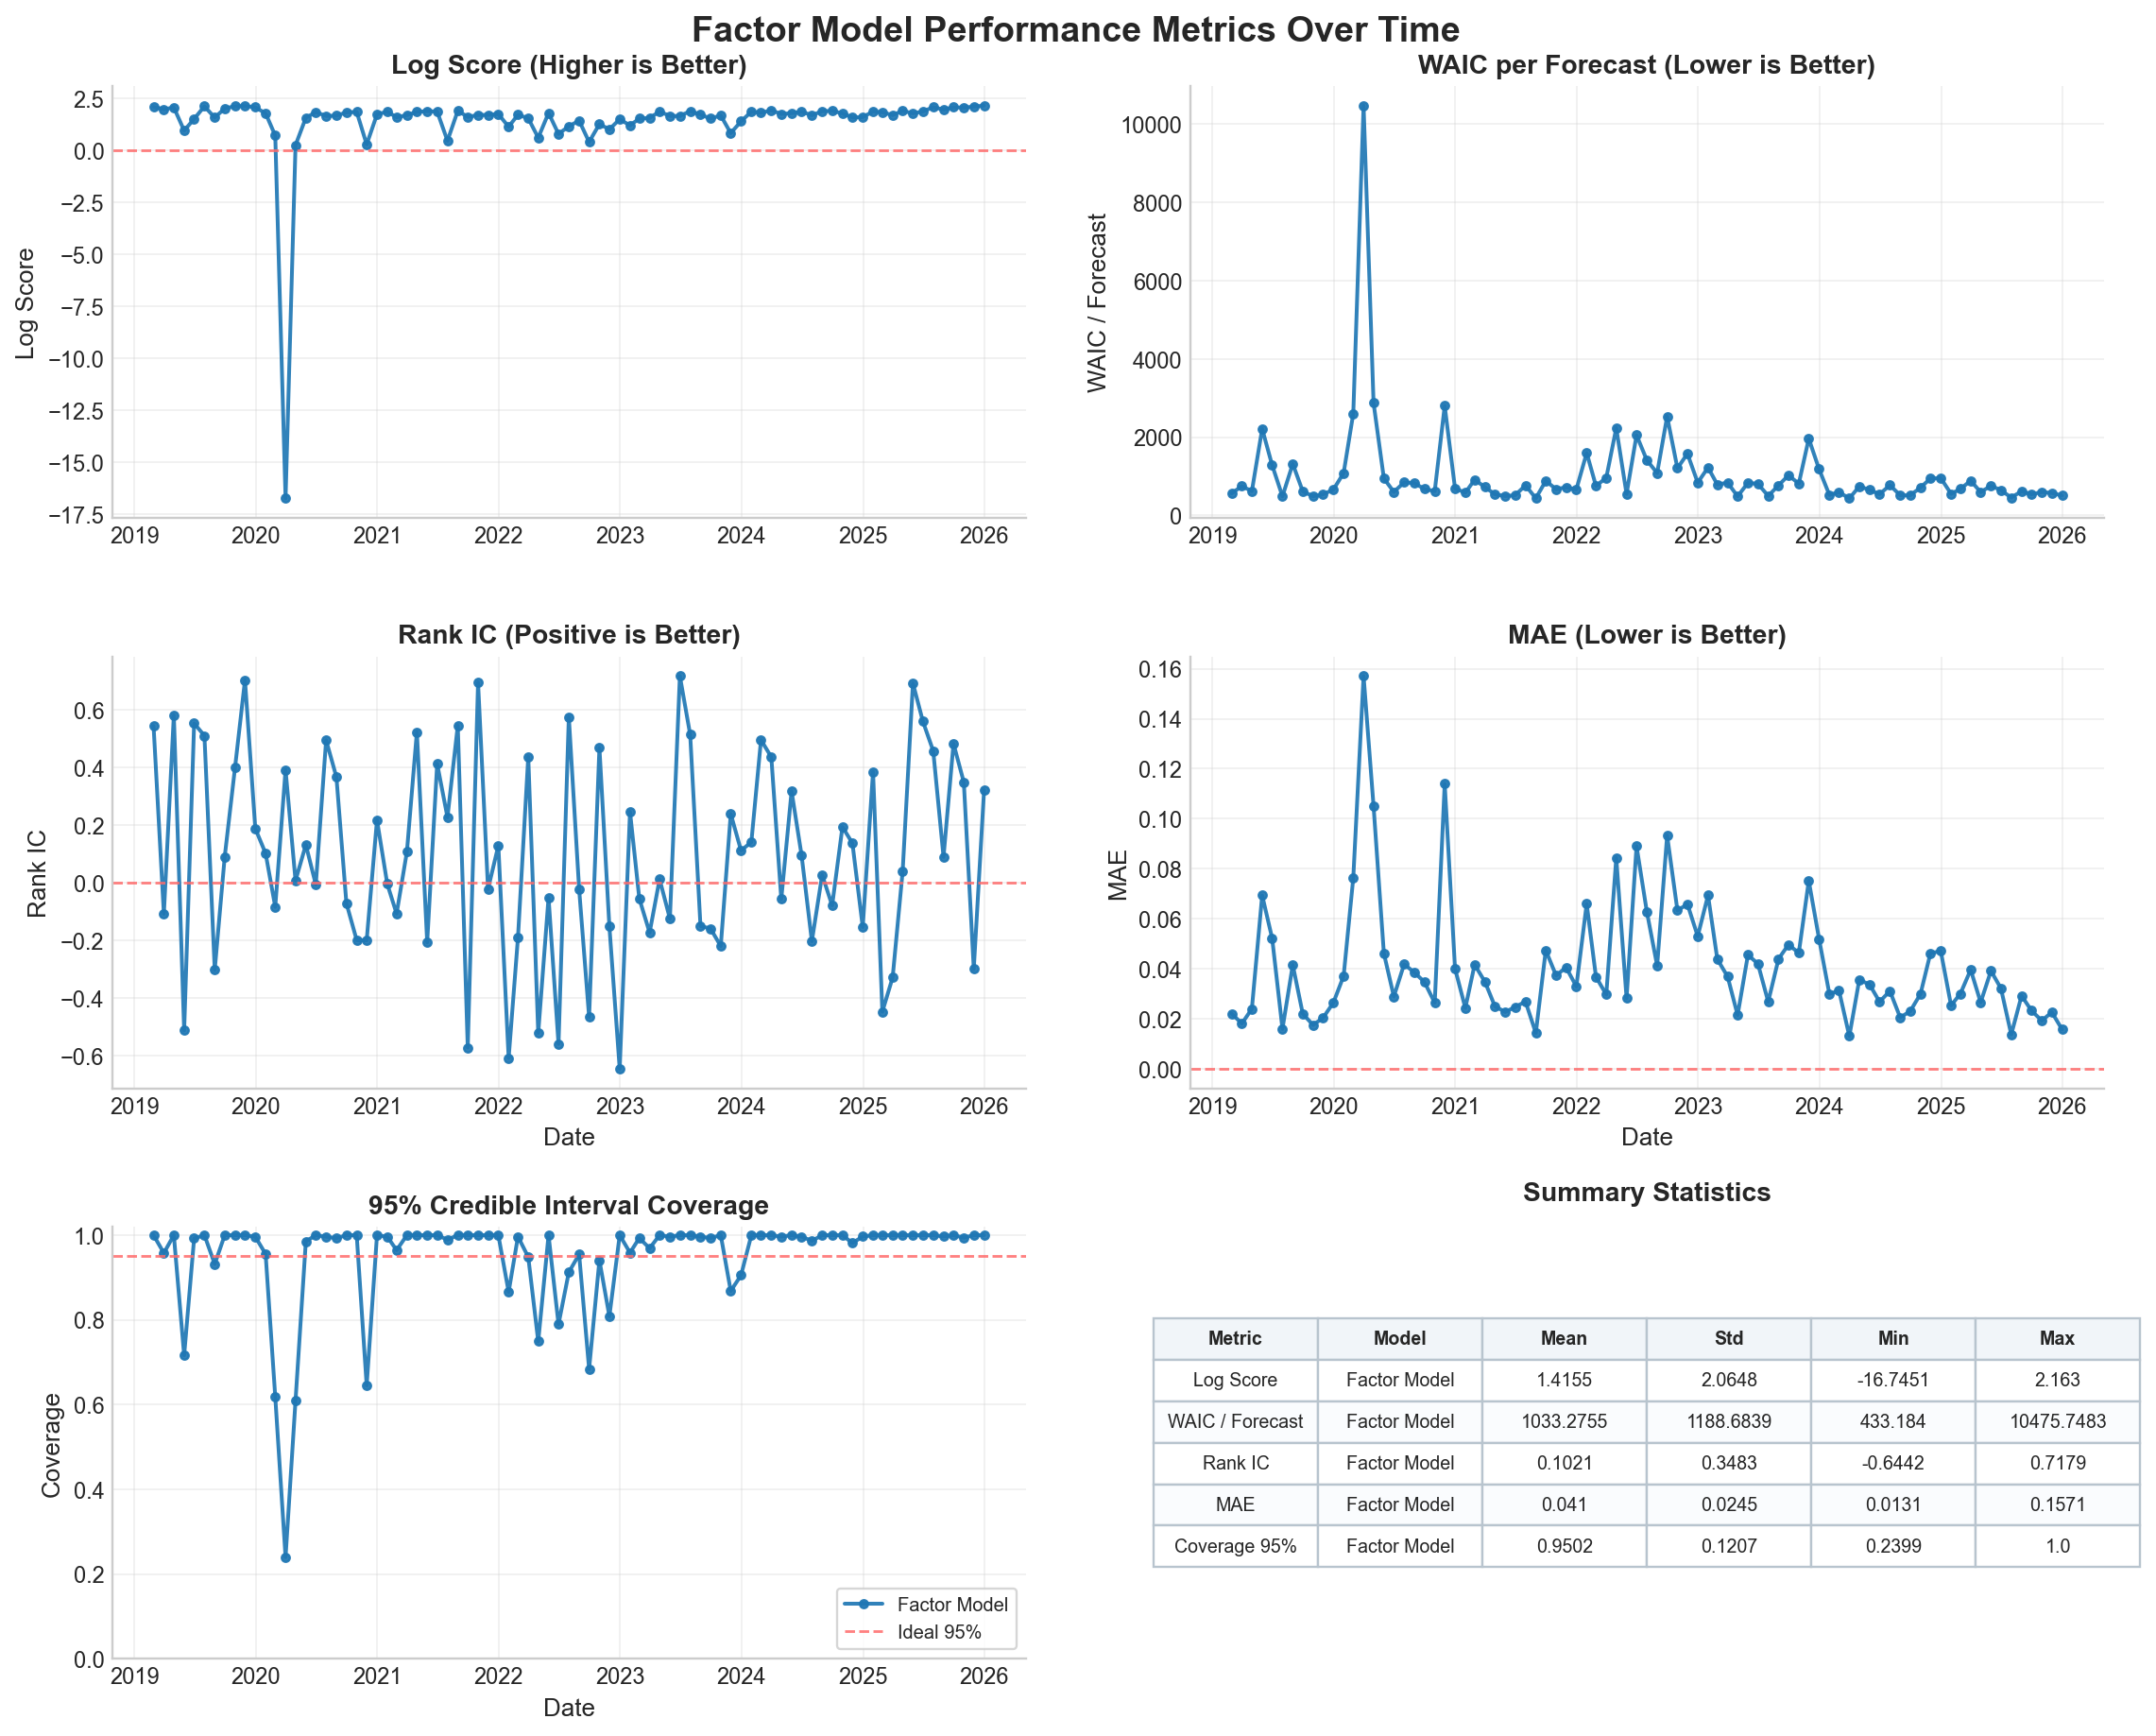

,Metric,Model,mean,std,min,max
0,Log Score,Factor Model,1.4155,2.0648,-16.7451,2.1630
1,WAIC / Forecast,Factor Model,1033.2755,1188.6839,433.1840,10475.7483
2,Rank IC,Factor Model,0.1021,0.3483,-0.6442,0.7179
3,MAE,Factor Model,0.0410,0.0245,0.0131,0.1571
4,Coverage 95%,Factor Model,0.9502,0.1207,0.2399,1.0000


In [ ]:
# Factor-model metrics chart and summary table
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

factor_label = "Factor Model"

def find_factor_model_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "model_by_month.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing notebooks/model_by_month.csv")

project_root = Path(globals().get("PROJECT_ROOT", find_factor_model_root(Path.cwd())))
factor_fallback_path = project_root / "notebooks" / "model_by_month.csv"

if "model_by_month" in globals():
    factor_metrics = model_by_month.copy()
else:
    factor_metrics = pd.read_csv(factor_fallback_path)

factor_metrics = factor_metrics.rename(
    columns={
        "prediction_date": "Date",
        "mean_log_score": "log_score",
        "coverage": "coverage_95",
    }
)[["Date", "log_score", "waic", "rank_ic", "mae", "coverage_95", "n_forecasts"]].copy()

factor_metrics["Date"] = pd.to_datetime(factor_metrics["Date"]).dt.to_period("M").dt.to_timestamp("M")
factor_metrics = factor_metrics.sort_values("Date").drop_duplicates("Date", keep="last")
factor_metrics["waic"] = factor_metrics["waic"].div(factor_metrics["n_forecasts"].replace(0, pd.NA))

metrics_config = {
    "log_score": {"title": "Log Score (Higher is Better)", "ylabel": "Log Score", "reference": 0.0},
    "waic": {"title": "WAIC per Forecast (Lower is Better)", "ylabel": "WAIC / Forecast", "reference": None},
    "rank_ic": {"title": "Rank IC (Positive is Better)", "ylabel": "Rank IC", "reference": 0.0},
    "mae": {"title": "MAE (Lower is Better)", "ylabel": "MAE", "reference": 0.0},
    "coverage_95": {"title": "95% Credible Interval Coverage", "ylabel": "Coverage", "reference": 0.95},
}

summary_stats = (
    factor_metrics
    .melt(id_vars=["Date"], value_vars=list(metrics_config), var_name="Metric", value_name="Value")
    .dropna(subset=["Value"])
    .groupby("Metric")["Value"]
    .agg(mean="mean", std="std", min="min", max="max")
    .reset_index()
)

metric_labels = {
    "log_score": "Log Score",
    "waic": "WAIC / Forecast",
    "rank_ic": "Rank IC",
    "mae": "MAE",
    "coverage_95": "Coverage 95%",
}

summary_stats["Metric"] = pd.Categorical(
    summary_stats["Metric"].map(metric_labels),
    categories=[metric_labels[key] for key in metrics_config],
    ordered=True,
)
summary_stats = summary_stats.sort_values("Metric").reset_index(drop=True)
summary_stats.insert(1, "Model", factor_label)
summary_stats[["mean", "std", "min", "max"]] = summary_stats[["mean", "std", "min", "max"]].round(4)

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 11), dpi=170)
gs = fig.add_gridspec(3, 2, hspace=0.32, wspace=0.18)

axes = {
    "log_score": fig.add_subplot(gs[0, 0]),
    "waic": fig.add_subplot(gs[0, 1]),
    "rank_ic": fig.add_subplot(gs[1, 0]),
    "mae": fig.add_subplot(gs[1, 1]),
    "coverage_95": fig.add_subplot(gs[2, 0]),
}
table_ax = fig.add_subplot(gs[2, 1])
table_ax.axis("off")

line_color = "#1f77b4"
marker_style = "o"

for metric, config in metrics_config.items():
    ax = axes[metric]
    ax.scatter(hist["prediction_date"], hist["realized_value"], s=35, color="black", label="Realized")
    )

    if config["reference"] is not None:
        ref_label = "Ideal 95%" if metric == "coverage_95" else None
        ax.axhline(config["reference"], color="#ff6b6b", linestyle="--", linewidth=1.2, alpha=0.85, label=ref_label)

    ax.set_title(config["title"], fontsize=12, fontweight="bold")
    ax.set_ylabel(config["ylabel"])
    ax.grid(True, alpha=0.28)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)

axes["coverage_95"].set_ylim(0, 1.02)
axes["coverage_95"].set_xlabel("Date")
axes["mae"].set_xlabel("Date")
axes["rank_ic"].set_xlabel("Date")
axes["coverage_95"].legend(loc="lower right", frameon=True, fontsize=8.5)

table_ax.set_title("Summary Statistics", fontsize=12, fontweight="bold", pad=12)
table = table_ax.table(
    cellText=summary_stats.values.tolist(),
    colLabels=["Metric", "Model", "Mean", "Std", "Min", "Max"],
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.3)
table.scale(1.08, 1.34)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#B8C4CE")
    if row == 0:
        cell.set_facecolor("#F1F5F9")
        cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#FAFCFE")

fig.suptitle("Factor Model Performance Metrics Over Time", fontsize=16, fontweight="bold", y=0.98)
fig.subplots_adjust(top=0.94, bottom=0.05)
plt.show()

display(summary_stats)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hierarchical_portfolio_backtest import _build_model_config
from hierarchical_bayesian_etf_model import _resolve_factor_columns, _transform_macro_block, _standardize_block

# pick the result object already in memory
result = factor_model if "factor_model" in globals() else backtest_result

factor_loadings_by_date = result["factor_loadings_by_date"]
residual_variance_by_date = result["residual_variance_by_date"]
diagnostics_table = result["diagnostics_table"].copy()
backtest_config = result["config"]
model_config = _build_model_config(backtest_config)

if not factor_loadings_by_date:
    raise ValueError("No factor loadings found in the result object.")

def _build_standardized_factor_history(train_start, train_end):
    macro_train = macro_factors_df.loc[train_start:train_end].copy()
    equity_columns = _resolve_factor_columns(
        requested_columns=model_config.equity_style_columns,
        available_columns=equity_factors_df.columns,
        factor_family="equity",
        factor_toggles=model_config.factor_toggles,
        factor_toggle_default=model_config.factor_toggle_default,
    )
    bond_columns = _resolve_factor_columns(
        requested_columns=model_config.bond_style_columns,
        available_columns=bond_factors_df.columns,
        factor_family="bond",
        factor_toggles=model_config.factor_toggles,
        factor_toggle_default=model_config.factor_toggle_default,
    )
    equity_train = equity_factors_df.loc[train_start:train_end, equity_columns].copy()
    bond_train = bond_factors_df.loc[train_start:train_end, bond_columns].copy()

    macro_block_raw, _ = _transform_macro_block(macro_train, model_config)

    macro_z, _, _ = _standardize_block(macro_block_raw)
    equity_z, _, _ = _standardize_block(equity_train)
    bond_z, _, _ = _standardize_block(bond_train)

    common_index = (
        macro_z.index
        .intersection(equity_z.index)
        .intersection(bond_z.index)
        .sort_values()
    )

    macro_z = macro_z.loc[common_index].add_prefix("macro::")
    equity_z = equity_z.loc[common_index].add_prefix("equity::")
    bond_z = bond_z.loc[common_index].add_prefix("bond::")

    return pd.concat([macro_z, equity_z, bond_z], axis=1).sort_index()

def _factor_variance_from_history(factor_history, factor_names, forecast_mode):
    factor_names = pd.Index(factor_names)
    out = pd.Series(index=factor_names, dtype=float)

    if forecast_mode == "mean_zero":
        out.loc[:] = 1.0
        return out

    if forecast_mode != "ar1":
        raise ValueError(f"Unsupported forecast_mode: {forecast_mode}")

    for factor_name in factor_names:
        if factor_name not in factor_history.columns:
            out.loc[factor_name] = np.nan
            continue

        series = factor_history[factor_name].dropna().astype(float)

        # Mirrors the model logic:
        # short history -> N(0,1), otherwise AR(1) shock variance
        if len(series) < 3:
            out.loc[factor_name] = 1.0
            continue

        x_prev = series.iloc[:-1].to_numpy(dtype=float)
        x_next = series.iloc[1:].to_numpy(dtype=float)
        denom = float(np.dot(x_prev, x_prev))
        phi = 0.0 if denom <= 1e-12 else float(np.dot(x_prev, x_next) / denom)
        phi = float(np.clip(phi, -0.99, 0.99))
        resid = x_next - phi * x_prev
        shock_std = float(np.std(resid, ddof=0))
        shock_std = max(shock_std, 0.25)

        out.loc[factor_name] = shock_std ** 2

    return out

def _decompose_one_date(dt):
    loadings = factor_loadings_by_date[dt].drop(columns=["alpha"], errors="ignore").copy().astype(float)
    resid = residual_variance_by_date[dt].copy().astype(float)

    row = diagnostics_table.loc[dt]
    train_start = pd.Timestamp(row["train_start"])
    train_end = pd.Timestamp(row["train_end"])

    factor_history = _build_standardized_factor_history(train_start, train_end)

    common_assets = loadings.index.intersection(resid.index)
    common_factors = loadings.columns.intersection(factor_history.columns)

    if len(common_assets) == 0 or len(common_factors) == 0:
        raise ValueError(f"No overlapping assets/factors for {dt}.")

    B = loadings.loc[common_assets, common_factors].fillna(0.0)
    D = resid.loc[common_assets].fillna(0.0)
    factor_var = _factor_variance_from_history(
        factor_history=factor_history,
        factor_names=common_factors,
        forecast_mode=model_config.forecast_mode,
    ).fillna(0.0)

    # Independent-factor contribution under this model:
    # contribution_{asset,factor} = beta^2 * Var(factor)
    factor_contrib_by_asset = (B ** 2).mul(factor_var, axis=1)

    explained_var_by_asset = factor_contrib_by_asset.sum(axis=1).rename("explained_variance")
    unexplained_var_by_asset = D.rename("unexplained_variance")
    total_var_by_asset = (explained_var_by_asset + unexplained_var_by_asset).rename("total_variance")
    explained_share_by_asset = (
        explained_var_by_asset / total_var_by_asset.replace(0, np.nan)
    ).rename("explained_share")

    asset_summary = pd.concat(
        [explained_var_by_asset, unexplained_var_by_asset, total_var_by_asset, explained_share_by_asset],
        axis=1
    ).sort_values("explained_share", ascending=False)

    factor_summary = pd.DataFrame({
        "factor_variance": factor_var,
        "variance_contribution": factor_contrib_by_asset.sum(axis=0),
    }).sort_values("variance_contribution", ascending=False)

    factor_summary["share_of_explained_variance"] = (
        factor_summary["variance_contribution"] /
        factor_summary["variance_contribution"].sum()
    )
    factor_summary["share_of_total_variance"] = (
        factor_summary["variance_contribution"] /
        total_var_by_asset.sum()
    )

    portfolio_summary = pd.Series({
        "date": dt,
        "n_assets": len(common_assets),
        "explained_variance": explained_var_by_asset.sum(),
        "unexplained_variance": unexplained_var_by_asset.sum(),
        "total_variance": total_var_by_asset.sum(),
        "explained_share": explained_var_by_asset.sum() / total_var_by_asset.sum(),
        "unexplained_share": unexplained_var_by_asset.sum() / total_var_by_asset.sum(),
    }, name="portfolio_summary")

    return {
        "asset_summary": asset_summary,
        "factor_summary": factor_summary,
        "portfolio_summary": portfolio_summary,
        "factor_contrib_by_asset": factor_contrib_by_asset,
    }

# ---------- latest date ----------
latest_date = sorted(factor_loadings_by_date.keys())[-1]
latest = _decompose_one_date(latest_date)

print("Latest rebalance date:", latest_date)
display(latest["portfolio_summary"].to_frame())
display(latest["factor_summary"])
display(latest["asset_summary"])

# ---------- timeline ----------
timeline_rows = []
per_factor_rows = []

for dt in sorted(factor_loadings_by_date.keys()):
    try:
        dec = _decompose_one_date(dt)
    except Exception:
        continue

    ps = dec["portfolio_summary"]
    timeline_rows.append(ps.to_dict())

    fs = dec["factor_summary"]["share_of_total_variance"].rename(dt)
    per_factor_rows.append(fs)

timeline_df = pd.DataFrame(timeline_rows).set_index("date").sort_index()
factor_timeline_df = pd.DataFrame(per_factor_rows).sort_index()

display(timeline_df.tail())
display(factor_timeline_df.tail())

variance_palette = {
    "navy": "#0B3C5D",
    "blue": "#328CC1",
    "green": "#5AA469",
    "orange": "#F26419",
    "grid": "#D7DEE5",
}

fig, axes = plt.subplots(2, 1, figsize=(11.2, 10.4), sharex=True, gridspec_kw={"hspace": 0.28})
fig.patch.set_facecolor("white")
for ax in axes:
    ax.set_facecolor("white")
    ax.grid(True, axis="y", color=variance_palette["grid"], alpha=0.9, linewidth=0.9)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(variance_palette["grid"])
    ax.spines["bottom"].set_color(variance_palette["grid"])

timeline_df[["explained_share", "unexplained_share"]].plot(
    ax=axes[0],
    lw=2.6,
    color=[variance_palette["blue"], variance_palette["orange"]],
)
axes[0].set_title("Explained vs Unexplained Variance Over Time", fontsize=13, fontweight="bold", color=variance_palette["navy"])
axes[0].set_ylabel("Share of total variance", fontsize=11, color=variance_palette["navy"])
axes[0].tick_params(axis="both", labelsize=10, colors=variance_palette["navy"])
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=True, fontsize=9)

if not factor_timeline_df.empty:
    factor_colors = [variance_palette["navy"], variance_palette["blue"], variance_palette["green"], variance_palette["orange"], "#7B8C99", "#A23B72", "#6C9A8B", "#C97B84"]
    factor_timeline_df.plot(ax=axes[1], lw=1.9, color=factor_colors[:factor_timeline_df.shape[1]])
    axes[1].set_title("Per-factor Contribution to Total Variance Over Time", fontsize=13, fontweight="bold", color=variance_palette["navy"])
    axes[1].set_ylabel("Share of total variance", fontsize=11, color=variance_palette["navy"])
    axes[1].tick_params(axis="both", labelsize=10, colors=variance_palette["navy"])
    axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=True, fontsize=8.5)

axes[1].set_xlabel("Rebalance date", fontsize=11, color=variance_palette["navy"])
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

def _get_draw_dict(backtest_result, draw_source="scenario"):
    if draw_source == "scenario":
        return backtest_result["scenario_matrix_by_date"]
    if draw_source == "posterior":
        return backtest_result["posterior_draws_by_date"]
    if draw_source == "posterior_predictive":
        return backtest_result["posterior_predictive_draws_by_date"]
    raise ValueError("draw_source must be 'scenario', 'posterior', or 'posterior_predictive'")


def _build_ticker_history(backtest_result, ticker, draw_source="scenario", interval_level=0.95):
    scores = backtest_result["forecast_scores_table"].copy()
    if scores.empty:
        raise ValueError("forecast_scores_table is empty.")

    scores["rebalance_date"] = pd.to_datetime(scores["rebalance_date"])
    scores["prediction_date"] = pd.to_datetime(scores["prediction_date"])
    scores = scores[scores["etf"] == ticker].copy()

    if scores.empty:
        raise ValueError(f"{ticker} is not present in forecast_scores_table.")

    if draw_source == "scenario":
        out = scores[
            [
                "rebalance_date",
                "prediction_date",
                "etf",
                "predictive_mean",
                "predictive_std",
                "realized_value",
                "interval_lower",
                "interval_upper",
                "interval_hit",
                "abs_error",
                "crps",
                "log_score",
            ]
        ].sort_values("prediction_date")
        return out.reset_index(drop=True)

    draw_dict = _get_draw_dict(backtest_result, draw_source=draw_source)
    alpha = 1.0 - float(interval_level)
    rows = []

    for rebalance_date, draw_df in draw_dict.items():
        rebalance_date = pd.to_datetime(rebalance_date)
        if ticker not in draw_df.columns:
            continue

        row = scores[scores["rebalance_date"] == rebalance_date]
        if row.empty:
            continue

        draws = draw_df[ticker].dropna().to_numpy(dtype=float)
        if draws.size == 0:
            continue

        realized_value = float(row["realized_value"].iloc[0])
        pred_date = pd.to_datetime(row["prediction_date"].iloc[0])
        pred_mean = float(np.mean(draws))
        pred_std = float(np.std(draws, ddof=1)) if draws.size > 1 else 0.0
        lower = float(np.quantile(draws, alpha / 2.0))
        upper = float(np.quantile(draws, 1.0 - alpha / 2.0))

        rows.append(
            {
                "rebalance_date": rebalance_date,
                "prediction_date": pred_date,
                "etf": ticker,
                "predictive_mean": pred_mean,
                "predictive_std": pred_std,
                "realized_value": realized_value,
                "interval_lower": lower,
                "interval_upper": upper,
                "interval_hit": float(lower <= realized_value <= upper),
                "abs_error": float(abs(pred_mean - realized_value)),
                "crps": np.nan,
                "log_score": np.nan,
            }
        )

    out = pd.DataFrame(rows).sort_values("prediction_date")
    if out.empty:
        raise ValueError(f"No {draw_source} draws found for {ticker}.")
    return out.reset_index(drop=True)


def _filter_history_dates(hist, start=None, end=None):
    if start is not None:
        hist = hist[hist["prediction_date"] >= pd.to_datetime(start)]
    if end is not None:
        hist = hist[hist["prediction_date"] <= pd.to_datetime(end)]
    return hist.reset_index(drop=True)


def _summarize_ticker_history(hist):
    interval_width = hist["interval_upper"] - hist["interval_lower"]
    return {
        "n_obs": int(len(hist)),
        "coverage": float(hist["interval_hit"].mean()),
        "mae": float(hist["abs_error"].mean()),
        "crps": float(hist["crps"].mean()) if hist["crps"].notna().any() else np.nan,
        "realized_vol": float(hist["realized_value"].std(ddof=1)) if len(hist) > 1 else 0.0,
        "avg_interval_width": float(interval_width.mean()),
    }


def _rank_tickers_by_interval_tightness(
    backtest_result,
    draw_source="scenario",
    interval_level=0.95,
    start=None,
    end=None,
    min_obs=36,
):
    scores = backtest_result["forecast_scores_table"].copy()
    if scores.empty:
        raise ValueError("forecast_scores_table is empty.")

    rows = []
    for ticker in sorted(scores["etf"].dropna().unique()):
        try:
            hist = _build_ticker_history(
                backtest_result=backtest_result,
                ticker=ticker,
                draw_source=draw_source,
                interval_level=interval_level,
            )
        except ValueError:
            continue

        hist = _filter_history_dates(hist, start=start, end=end)
        if hist.empty or len(hist) < int(min_obs):
            continue

        summary = _summarize_ticker_history(hist)
        rows.append(
            {
                "ticker": ticker,
                "coverage": summary["coverage"],
                "mae": summary["mae"],
                "crps": summary["crps"],
                "realized_vol": summary["realized_vol"],
                "avg_interval_width": summary["avg_interval_width"],
                "n_obs": summary["n_obs"],
            }
        )

    ranking = pd.DataFrame(rows)
    if ranking.empty:
        raise ValueError("No tickers available after filtering. Try widening the date range or lowering min_obs.")

    return ranking.sort_values(["avg_interval_width", "coverage", "ticker"], ascending=[True, False, True]).reset_index(drop=True)


def _select_requested_assets(ranking, selected_tickers, label_map=None):
    if ranking.empty:
        raise ValueError("Ranking table is empty.")

    if not selected_tickers:
        raise ValueError("selected_tickers must contain at least one ticker.")

    label_map = label_map or {}
    available_tickers = set(ranking["ticker"])
    missing = [ticker for ticker in selected_tickers if ticker not in available_tickers]
    if missing:
        raise ValueError(f"Requested tickers are unavailable after filtering: {missing}")

    return [(label_map.get(ticker, "Selected"), ticker) for ticker in selected_tickers]


def _select_tight_interval_assets(ranking, n_high=2, n_low=2):
    if ranking.empty:
        raise ValueError("Ranking table is empty.")

    coverage_median = float(ranking["coverage"].median())
    high_pool = ranking[ranking["coverage"] >= coverage_median].copy()
    low_pool = ranking[ranking["coverage"] < coverage_median].copy()

    if len(high_pool) < int(n_high):
        high_pool = ranking.sort_values(["coverage", "avg_interval_width", "ticker"], ascending=[False, True, True]).copy()
    else:
        high_pool = high_pool.sort_values(["avg_interval_width", "coverage", "ticker"], ascending=[True, False, True]).copy()

    if len(low_pool) < int(n_low):
        low_pool = ranking.sort_values(["coverage", "avg_interval_width", "ticker"], ascending=[True, True, True]).copy()
    else:
        low_pool = low_pool.sort_values(["avg_interval_width", "coverage", "ticker"], ascending=[True, True, True]).copy()

    selected = []
    used = set()

    for _, row in high_pool.iterrows():
        ticker = row["ticker"]
        if ticker in used:
            continue
        selected.append(("High coverage", ticker))
        used.add(ticker)
        if sum(label == "High coverage" for label, _ in selected) >= int(n_high):
            break

    for _, row in low_pool.iterrows():
        ticker = row["ticker"]
        if ticker in used:
            continue
        selected.append(("Low coverage", ticker))
        used.add(ticker)
        if sum(label == "Low coverage" for label, _ in selected) >= int(n_low):
            break

    if len(selected) < int(n_high) + int(n_low):
        fallback = ranking.sort_values(["avg_interval_width", "coverage", "ticker"], ascending=[True, False, True])
        for _, row in fallback.iterrows():
            ticker = row["ticker"]
            if ticker in used:
                continue
            label = "Fallback"
            selected.append((label, ticker))
            used.add(ticker)
            if len(selected) >= int(n_high) + int(n_low):
                break

    return selected


def _plot_scenario_history_panel(ax, hist, ticker, interval_level, panel_label=None, show_legend=False):
    summary = _summarize_ticker_history(hist)

    ax.fill_between(
        hist["prediction_date"],
        hist["interval_lower"],
        hist["interval_upper"],
        alpha=0.25,
        label=f"{int(interval_level * 100)}% interval",
    )
    ax.plot(hist["prediction_date"], hist["predictive_mean"], lw=2, color="tab:blue", label="Predictive mean")
    ax.scatter(hist["prediction_date"], hist["realized_value"], s=35, color="black", label="Realized")
    ax.axhline(0.0, color="gray", lw=1, alpha=0.7)

    title = (
        f"{panel_label} | {ticker} | width={summary['avg_interval_width']:.4f}, coverage={summary['coverage']:.1%}"
        f", MAE={summary['mae']:.4f}, n={summary['n_obs']}"
    )
    if not np.isnan(summary["crps"]):
        title += f", CRPS={summary['crps']:.4f}"

    ax.set_title(title)
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(loc="best")


def plot_tight_interval_coverage_dashboard(
    backtest_result,
    draw_source="scenario",
    interval_level=0.95,
    start=None,
    end=None,
    min_obs=36,
    n_high=2,
    n_low=2,
    selected_tickers=None,
    selected_labels=None,
):
    ranking = _rank_tickers_by_interval_tightness(
        backtest_result=backtest_result,
        draw_source=draw_source,
        interval_level=interval_level,
        start=start,
        end=end,
        min_obs=min_obs,
    )
    if selected_tickers is not None:
        selected = _select_requested_assets(ranking, selected_tickers, label_map=selected_labels)
        figure_title = f"Scenario intervals: selected assets ({draw_source})"
    else:
        selected = _select_tight_interval_assets(ranking, n_high=n_high, n_low=n_low)
        figure_title = f"Scenario intervals: high vs low coverage ({draw_source})"

    fig, axes = plt.subplots(len(selected), 1, figsize=(18, 4.8 * len(selected)), squeeze=False)
    fig.suptitle(
        figure_title,
        fontsize=16,
        y=1.02,
    )

    selected_rows = []
    for row_idx, (group_label, ticker) in enumerate(selected):
        hist = _filter_history_dates(
            _build_ticker_history(
                backtest_result=backtest_result,
                ticker=ticker,
                draw_source=draw_source,
                interval_level=interval_level,
            ),
            start=start,
            end=end,
        )
        panel_label = group_label if selected_tickers is not None else f"{group_label} #{1 + sum(lbl == group_label for lbl, _ in selected[:row_idx])}"
        _plot_scenario_history_panel(
            axes[row_idx, 0],
            hist,
            ticker,
            interval_level,
            panel_label=panel_label,
            show_legend=(row_idx == 0),
        )
        row_summary = ranking[ranking["ticker"] == ticker].iloc[0].to_dict()
        row_summary["group"] = group_label
        selected_rows.append(row_summary)

    axes[-1, 0].set_xlabel("Prediction month")
    plt.tight_layout()
    plt.show()

    selected_table = pd.DataFrame(selected_rows).reset_index(drop=True)
    return ranking, selected_table


DRAW_SOURCE = "scenario"
INTERVAL_LEVEL = 0.95
START = None
END = None
MIN_OBS = 36
N_HIGH = 2
N_LOW = 2
# Replace SPY below if you want a different equity ETF proxy.
SELECTED_TICKERS = ["BIL", "ISTB", "SPY"]
SELECTED_LABELS = {
    "BIL": "Cash proxy",
    "ISTB": "Short-duration bond",
    "SPY": "Equity ETF",
}

ranking_table, selected_table = plot_tight_interval_coverage_dashboard(
    backtest_result=backtest_result,
    draw_source=DRAW_SOURCE,
    interval_level=INTERVAL_LEVEL,
    start=START,
    end=END,
    min_obs=MIN_OBS,
    n_high=N_HIGH,
    n_low=N_LOW,
    selected_tickers=SELECTED_TICKERS,
    selected_labels=SELECTED_LABELS,
)

display(selected_table)
display(ranking_table)

plt.axhline(0.50, color="gray", linestyle="--", linewidth=1)
plt.axvline(0.50, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Stability Score")
plt.ylabel("Importance Score")
plt.title("Factor Assessment Map")
plt.legend()
plt.tight_layout()
plt.show()


